# Price Initializer — Clean Pipeline (Initial / Target / Lead-time Price)

Derives every price target from the per-horizon snapshots in the single anonymised
weekly extract (no separate price exports). All logic lives in `src/`; cells only
import, call and display.

**Flow**
1. Setup & load the weekly extract.
2. Derive `InitialPrice` / `InitialPriceLastYear` (price at the earliest priced horizon).
3. Train Ridge / Lasso / Random Forest on `InitialPrice` (the **imitator**); baselines + per-`SeasonalCluster` eval.
4. Coverage analysis to size the `%`-booked target.
5. Set `%` occupancy per season.
6. Derive `TargetPrice` / `TargetPriceLastYear`.
7. Train on `TargetPrice` (the **occupancy initializer**).
8. Derive & train the **lead-time-anchored initializer** (`LeadTimePrice`).
9. **Corrective** on-target lead-time experiment.
10. Compare the three models' **Random-Forest** predictions on the shared `ReservableOptionId`.

> **Scope — this is an LS (Low-Season) spring proof-of-concept.**
> A *real* `…LastYear` price exists only for 2025→2026 arrivals (2024 carries placeholder
> zeros), and the 2026 extract only reaches spring, so the held-out test window contains a
> single `SeasonalCluster` (`LS`). The metrics below are therefore **LS-only** and must not
> be read as a general price model — the pipeline prints a one-line warning whenever the
> test window collapses to one season. A

## Step 1 — Setup & Load Data

Put the repo root on `sys.path`, load the single weekly extract (reading `null`
as missing), and apply the mandatory `Capacity > 0` filter (and `RealOption` if
the column is present).

In [1]:
import logging
import sys
from pathlib import Path

import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.coverage_analysis import Columns, CoverageAnalyzer
from src.mekong_delta_price_features import PriceFeatureBuilder
from src.price_comparison import compare_rf_predictions, summarise_comparison
from src.price_model_pipeline import PipelineConfig, PriceModelPipeline

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")

DATA_PATH = REPO_ROOT / "data" / "raw" / "Mekong_Delta_Multiple_campsites_datasets_capacity_over_200_anonymised_final.csv"

df_weekly = pd.read_csv(DATA_PATH, low_memory=False, na_values=["null"])
if "RealOption" in df_weekly.columns:
    df_weekly = df_weekly[df_weekly["RealOption"] == True].copy()
df_weekly = df_weekly[df_weekly["Capacity"] > 0].copy()

print(f"weekly rows: {len(df_weekly):,}")
print(f"unique options: {df_weekly['ReservableOptionId'].nunique():,}")
print(f"arrival years: {sorted(pd.to_datetime(df_weekly['WeekStartDate']).dt.year.unique())}")
print(f"seasonal clusters: {sorted(df_weekly['SeasonalCluster'].dropna().unique())}")

weekly rows: 1,214,072
unique options: 3,842


arrival years: [np.int32(2024), np.int32(2025), np.int32(2026)]
seasonal clusters: ['HS', 'LS', 'S1', 'S2', 'WTR']


## Step 2 — Derive InitialPrice & InitialPriceLastYear

Collapse the market-group rows to one row per option-horizon, then build the
one-row-per-option-week feature table. `InitialPrice` is the discounted price at
the **earliest priced horizon** of the current season (highest
`WeekBeforeArrival` with a price); `InitialPriceLastYear` applies the same rule
to the last-year price series, resolved independently.

In [2]:
builder = PriceFeatureBuilder()

# Per-season demand lift-off lead time (weeks before arrival) — the point where
# demand begins. ONE editable dict driving BOTH the last-year early-pace feature
# below and the lead-time price target (Step 8).
LEAD_BY_SEASON = {"HS": 30, "S1": 30, "S2": 30, "LS": 20, "WTR": 20}

option_week = builder.build_option_week_table(df_weekly)
option_week = builder.add_initial_prices(df_weekly, option_week)
# Leakage-safe demand signal from the PRIOR-year booking curve (LastYearEarlyFill
# reads occupancy at the per-season LEAD_BY_SEASON lift-off), plus the realized
# final occupancy (FinalFill, used only for the Step 9 labels).
option_week = builder.add_demand_features(df_weekly, option_week, LEAD_BY_SEASON)
option_week = builder.add_last_year_dynamics(df_weekly, option_week)
option_week = builder.add_final_fill(df_weekly, option_week)

print(f"option-week rows: {len(option_week):,}")
print(f"InitialPrice non-null:   {option_week['InitialPrice'].notna().mean():.1%}")
print(f"InitialPriceLastYear:    {option_week['InitialPriceLastYear'].notna().mean():.1%}")

option_week[["ReservableOptionId", "WeekStartDate", "SeasonalCluster",
             "RangeOrdinal", "Capacity", "InitialPrice", "InitialPriceLastYear",
             "LastYearMaxFill", "FinalFill"]].head(10)

option-week rows: 3,842
InitialPrice non-null:   87.3%
InitialPriceLastYear:    44.0%


,ReservableOptionId,WeekStartDate,SeasonalCluster,RangeOrdinal,Capacity,InitialPrice,InitialPriceLastYear,LastYearMaxFill,FinalFill
0,82074122,2025-04-05,LS,2,321,47.00,NaN,NaN,0.367601
1,82074123,2025-08-16,HS,2,357,156.00,181.48,0.960714,0.988796
2,82074124,2025-07-26,HS,2,357,175.00,202.48,0.964286,0.963585
3,82074125,2025-08-02,HS,2,357,184.00,213.48,0.985612,0.971989
4,82074126,2025-09-20,S2,2,302,46.00,52.00,0.042857,0.466887
5,82074128,2025-07-05,HS,2,343,125.00,150.48,0.885714,0.798834
6,82074129,2025-08-09,HS,2,357,184.00,213.48,0.989286,0.988796
7,82074130,2024-09-14,S2,2,262,55.48,NaN,NaN,0.812977
8,82074131,2025-06-21,S1,2,307,63.00,94.48,0.905138,0.840391
9,82074132,2025-06-14,LS,2,323,64.50,73.48,0.965251,0.656347


## Step 3 — Train Ridge, Lasso & Random Forest on InitialPrice

The pipeline splits by arrival-week date masks (train season vs. held-out
season), drops rows with a missing target, mode-fills sparse categoricals,
one-hot encodes, median-imputes numeric features and standardises for the linear models (Ridge/Lasso).
It reports overall metrics against the global-mean and segment-mean baselines.

In [3]:
initial_config = PipelineConfig(
    target="InitialPrice",
    last_year_feature="InitialPriceLastYear",
)
initial_pipeline = PriceModelPipeline(initial_config)
initial_result = initial_pipeline.run(option_week)

initial_result.metrics.round(3)

train rows 543 | test rows 692
train WSD 2025-04-05 -> 2025-06-07
test  WSD 2026-03-28 -> 2026-05-30
y_train mean 58.3  y_test mean 51.0
!! test window holds ONE season ('LS') — metrics are a 'LS'-only proof-of-concept, not a general price model.


random forest best params: {'max_depth': 20, 'min_samples_leaf': 1}
   Baseline-mean | RMSE    16.09 | MAE    12.85 | R2 -0.257 | MAPE  28.6%
Baseline-segment | RMSE    12.01 | MAE     8.77 | R2  0.300 | MAPE  17.9%
           Ridge | RMSE    10.63 | MAE     8.02 | R2  0.452 | MAPE  16.7%
           Lasso | RMSE    10.32 | MAE     7.53 | R2  0.483 | MAPE  15.6%
    RandomForest | RMSE    10.11 | MAE     7.04 | R2  0.505 | MAPE  13.8%


,rmse,mae,r2,mape
Baseline-mean,16.095,12.853,-0.257,28.639
Baseline-segment,12.007,8.769,0.300,17.901
Ridge,10.627,8.018,0.452,16.685
Lasso,10.321,7.533,0.483,15.647
RandomForest,10.105,7.043,0.505,13.827


In [4]:
# Interpretation — Ridge coefficients (signed) and forest importances (magnitude)
print("Top Ridge price drivers (scaled features):")
print(initial_pipeline.ridge_coefficients(initial_result).to_string())
print("\nTop Random Forest features:")
print(initial_pipeline.rf_importances(initial_result).to_string())

Top Ridge price drivers (scaled features):
RangeOrdinal                       0.079646
InitialPriceLastYear               0.073045
CampsiteCodeGrouped_Campsite030    0.043374
SleepsNum                          0.031684
has_last_year                      0.028368
TV                                 0.027101
ArrivalMonth                       0.025463
Bathrooms                          0.025180
is_special_period                  0.024005
CampsiteCodeGrouped_Campsite017   -0.021031
LastYearEarlyFill                  0.020346
LastYearMaxFill                   -0.020068
Bedrooms                           0.017067
CampsiteCodeGrouped_Campsite018   -0.016640
Airco                              0.016132

Top Random Forest features:


InitialPriceLastYear               0.490334
RangeOrdinal                       0.148519
IsoWeek                            0.079701
Capacity                           0.069597
LastYearMaxFill                    0.037362
ArrivalMonth                       0.032606
LastYearEarlyFill                  0.028826
SleepsNum                          0.015916
Bedrooms                           0.014830
CampsiteCodeGrouped_Campsite018    0.010868
CampsiteCodeGrouped_Campsite013    0.010573
TV                                 0.009961
Bathrooms                          0.008795
CampsiteCodeGrouped_Campsite002    0.007868
DeckingType_Decking                0.003897


### Per-SeasonalCluster Evaluation (InitialPrice)

RMSE per `SeasonalCluster` for the segment baseline, Ridge, Lasso and the forest —
lower is better. (This LS-only window has a single tier.)

In [5]:
initial_result.per_cluster_rmse

,n,Baseline-segment,Ridge,Lasso,RandomForest
SeasonalCluster,,,,,
LS,692.0,12.01,10.63,10.32,10.11


## Step 4 — Coverage Analysis

Before defining the target price, `CoverageAnalyzer` shows how many option-weeks
actually reach each candidate `%`-booked level (overall and per Season × Region).
This sizes a defensible occupancy threshold per season.

In [6]:
analyzer = CoverageAnalyzer(df_weekly, columns=Columns(), min_lead_weeks=0)

thresholds = np.round(np.arange(0.10, 0.90 + 1e-9, 0.05), 8)
coverage_floor = 0.50

coverage_table = analyzer.summary_table(thresholds, coverage_floor).copy()
coverage_table.index = [f"{x:.0%}" for x in coverage_table.index]
pct_cols = ["global_coverage", "min_group_coverage", "median_group_coverage"]
coverage_table[pct_cols] = (coverage_table[pct_cols] * 100).round(1)
print("=== Coverage per candidate %-booked threshold (coverage in %) ===")
display(coverage_table)

print(f">>> Recommended threshold: X% = {analyzer.recommend(thresholds, coverage_floor):.0%} <<<")

INFO | Fill distribution (max per curve): median=0.49, p25=0.18, p75=0.74


INFO | 3842 curves (option x arrival-week) across 10 groups.


=== Coverage per candidate %-booked threshold (coverage in %) ===


,global_coverage,min_group_coverage,median_group_coverage,groups_below_floor
10%,81.1,48.6,79.5,1
15%,77.5,41.4,77.6,2
20%,73.6,32.8,72.8,2
25%,70.2,25.0,67.7,2
30%,66.1,20.3,60.8,2
35%,62.7,15.6,55.5,2
40%,58.6,14.1,51.7,5
45%,53.6,12.5,47.7,6
50%,48.8,10.9,43.1,7
55%,44.2,7.8,37.8,8


WARNING | No threshold keeps all groups above 50%. Best compromise: X%=10%.


>>> Recommended threshold: X% = 10% <<<


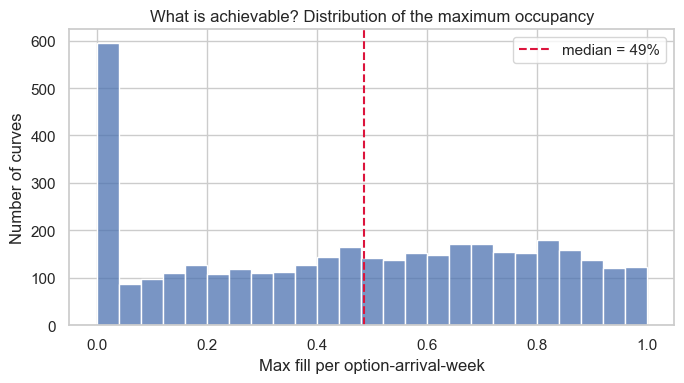

WARNING | No threshold keeps all groups above 50%. Best compromise: X%=10%.


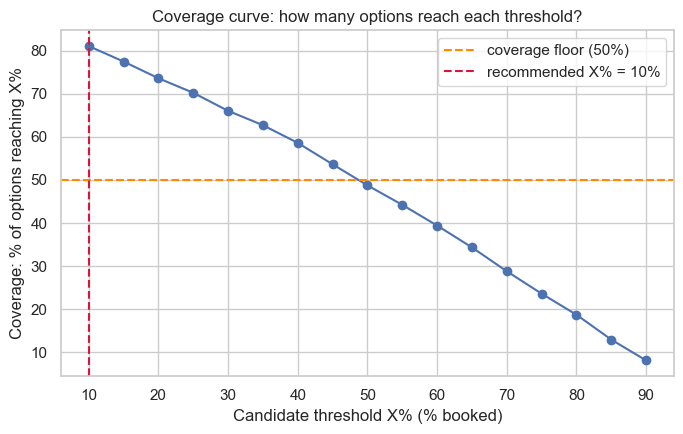

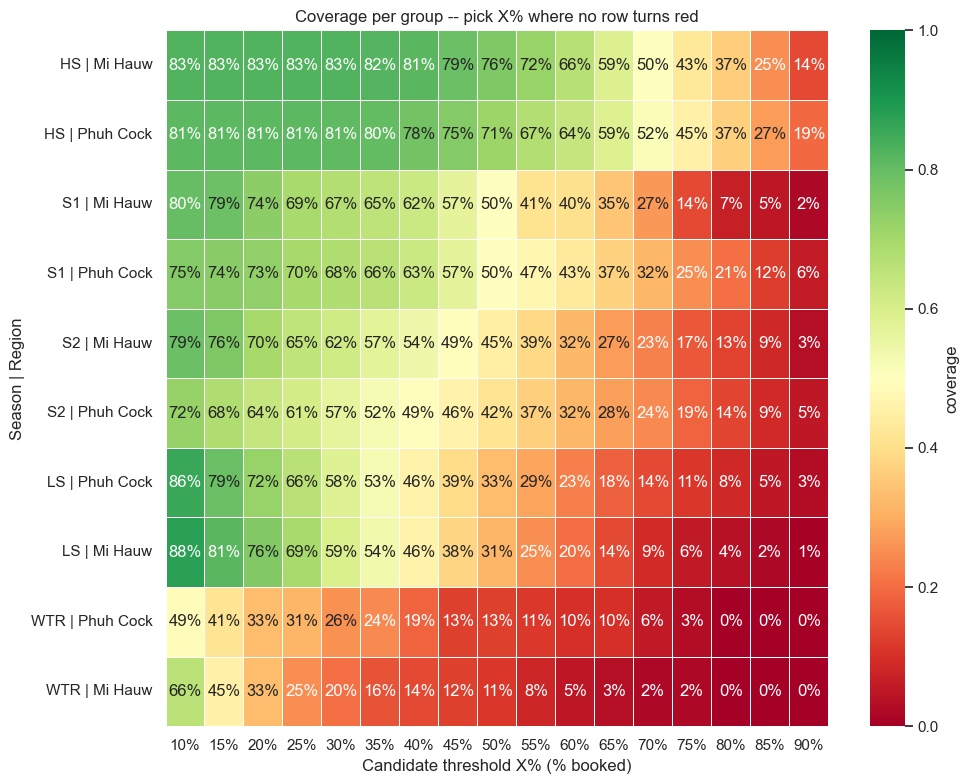

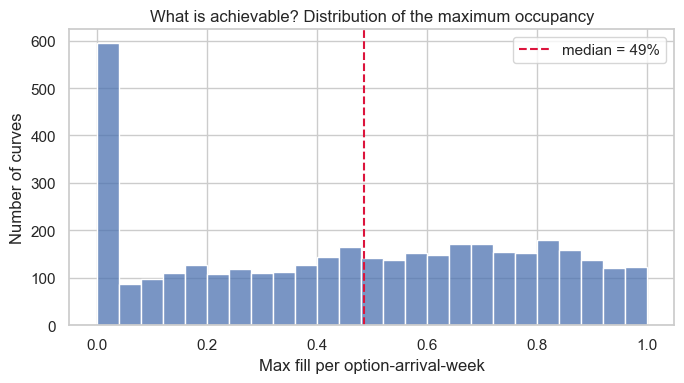

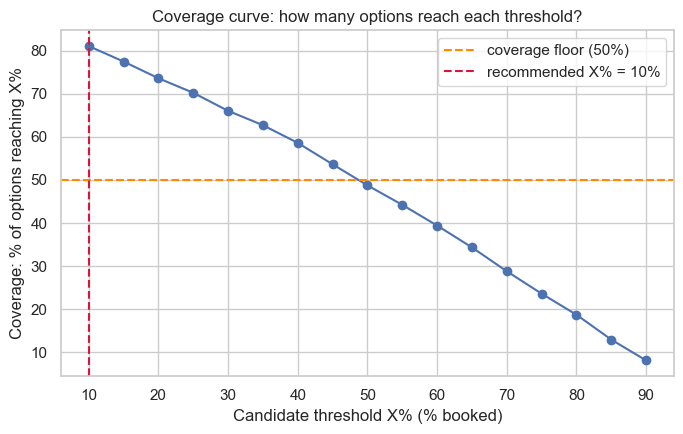

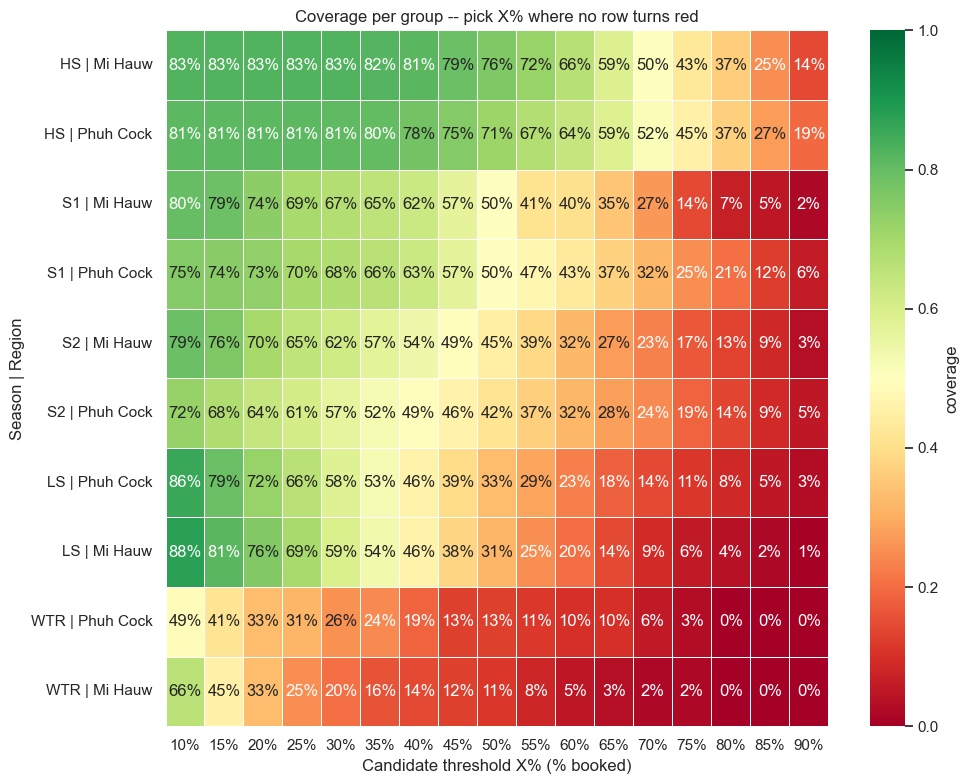

In [7]:
display(analyzer.plot_max_fill_distribution())
display(analyzer.plot_coverage_curve(thresholds, coverage_floor))
display(analyzer.plot_group_heatmap(thresholds))

## Step 5 — Set Target Occupancy per Season

Pick the `%` occupancy that defines the target price for each season code, guided
by the coverage analysis above. `TargetPrice` is read at the first horizon where
cumulative occupancy reaches this level. Edit the values below to re-anchor the
target.

In [8]:
# Target occupancy per season code (HS = High Season, LS = Low Season,
# S1/S2 = shoulder seasons, WTR = Winter). Adjust as needed.
season_occupancy = {
    "HS": 0.3,
    "LS": 0.2,
    "S1": 0.2,
    "S2": 0.2,
    "WTR": 0.10,
}
season_occupancy

{'HS': 0.3, 'LS': 0.2, 'S1': 0.2, 'S2': 0.2, 'WTR': 0.1}

## Step 6 — Derive TargetPrice & TargetPriceLastYear

Using `season_occupancy`, attach `TargetPrice` (current-season occupancy via
`CumulativeHistoricalBookedNights / Capacity`) and `TargetPriceLastYear` (last-year
occupancy via `CumulativeHistoricalBookedNightsLastYear / CapacityLastYear`).
Option-weeks that never reach their season threshold get `NaN` and are dropped
when the target model trains.

In [9]:
option_week = builder.add_target_prices(df_weekly, option_week, season_occupancy)

print(f"TargetPrice non-null:         {option_week['TargetPrice'].notna().mean():.1%}")
print(f"TargetPriceLastYear non-null: {option_week['TargetPriceLastYear'].notna().mean():.1%}")

option_week[["ReservableOptionId", "WeekStartDate", "SeasonalCluster",
             "InitialPrice", "InitialPriceLastYear",
             "TargetPrice", "TargetPriceLastYear"]].head(10)

TargetPrice non-null:         77.1%
TargetPriceLastYear non-null: 37.3%


,ReservableOptionId,WeekStartDate,SeasonalCluster,InitialPrice,InitialPriceLastYear,TargetPrice,TargetPriceLastYear
0,82074122,2025-04-05,LS,47.00,NaN,37.500000,NaN
1,82074123,2025-08-16,HS,156.00,181.48,197.500000,165.0
2,82074124,2025-07-26,HS,175.00,202.48,198.000000,179.0
3,82074125,2025-08-02,HS,184.00,213.48,229.000000,189.0
4,82074126,2025-09-20,S2,46.00,52.00,48.428571,NaN
5,82074128,2025-07-05,HS,125.00,150.48,134.000000,132.0
6,82074129,2025-08-09,HS,184.00,213.48,215.750000,189.0
7,82074130,2024-09-14,S2,55.48,NaN,51.750000,NaN
8,82074131,2025-06-21,S1,63.00,94.48,66.500000,91.0
9,82074132,2025-06-14,LS,64.50,73.48,69.392857,70.0


## Step 7 — Train Ridge, Lasso & Random Forest on TargetPrice

The identical pipeline now targets `TargetPrice`, with `TargetPriceLastYear` as
its paired last-year feature.

In [10]:
target_config = PipelineConfig(
    target="TargetPrice",
    last_year_feature="TargetPriceLastYear",
)
target_pipeline = PriceModelPipeline(target_config)
target_result = target_pipeline.run(option_week)

display(target_result.metrics.round(3))
print("\nRMSE per SeasonalCluster (TargetPrice):")
display(target_result.per_cluster_rmse)

train rows 410 | test rows 584
train WSD 2025-04-05 -> 2025-06-07
test  WSD 2026-03-28 -> 2026-05-30
y_train mean 56.9  y_test mean 48.8
!! test window holds ONE season ('LS') — metrics are a 'LS'-only proof-of-concept, not a general price model.


random forest best params: {'max_depth': 20, 'min_samples_leaf': 1}


   Baseline-mean | RMSE    16.35 | MAE    13.82 | R2 -0.323 | MAPE  32.2%
Baseline-segment | RMSE    12.99 | MAE    10.55 | R2  0.166 | MAPE  22.6%
           Ridge | RMSE    10.13 | MAE     7.42 | R2  0.492 | MAPE  15.6%
           Lasso | RMSE    10.15 | MAE     7.51 | R2  0.491 | MAPE  15.9%
    RandomForest | RMSE    10.56 | MAE     7.91 | R2  0.448 | MAPE  16.3%


,rmse,mae,r2,mape
Baseline-mean,16.354,13.818,-0.323,32.158
Baseline-segment,12.986,10.550,0.166,22.585
Ridge,10.134,7.417,0.492,15.551
Lasso,10.146,7.512,0.491,15.939
RandomForest,10.559,7.905,0.448,16.284



RMSE per SeasonalCluster (TargetPrice):


,n,Baseline-segment,Ridge,Lasso,RandomForest
SeasonalCluster,,,,,
LS,584.0,12.99,10.13,10.15,10.56


## Step 8 — Lead-time-anchored initializer (LeadTimePrice)

An alternative initializer target motivated by the EDA: instead of the price at an **X%-occupancy** threshold (which ~23% of options never reach), use the price **in market at the season's demand lift-off lead time**. The per-season lift-off lead times come from the shared **`LEAD_BY_SEASON`** dict defined in the Setup/Step-2 build cell (default `WeekBeforeArrival` 30 for HS/S1/S2, 20 for LS/WTR) — edit it there; it drives both this target and the early-pace feature. It is defined for far more options, so the model trains on a denser, less **right-censored** sample.

> ➡ **Decision:** lead-time anchoring sidesteps the occupancy target's censoring — it is the price a guest sees when demand begins, and trains on more rows. Across *different* targets, judge it on **coverage + MAPE**, not absolute R².

In [11]:
# Lead-time price uses the per-season LEAD_BY_SEASON from the Setup/Step-2 build cell
# (one shared lift-off, also driving the early-pace feature) — edit it there.
option_week = builder.add_lead_time_prices(df_weekly, option_week, LEAD_BY_SEASON)

leadtime_config = PipelineConfig(
    target="LeadTimePrice", last_year_feature="LeadTimePriceLastYear",
)
leadtime_pipeline = PriceModelPipeline(leadtime_config)
leadtime_result = leadtime_pipeline.run(option_week)
display(leadtime_result.metrics.round(3))

print("coverage / training rows (denser = less censored):")
print(f"  LeadTimePrice : {option_week['LeadTimePrice'].notna().mean():5.1%}  "
      f"train+test {len(leadtime_result.y_train)}+{len(leadtime_result.y_test)}")
print(f"  TargetPrice   : {option_week['TargetPrice'].notna().mean():5.1%}  "
      f"train+test {len(target_result.y_train)}+{len(target_result.y_test)}")
print("\nTop lead-time drivers (RF importances):")
print(leadtime_pipeline.rf_importances(leadtime_result, 10).round(3).to_string())


train rows 511 | test rows 679
train WSD 2025-04-05 -> 2025-06-07
test  WSD 2026-03-28 -> 2026-05-30
y_train mean 59.2  y_test mean 50.5
!! test window holds ONE season ('LS') — metrics are a 'LS'-only proof-of-concept, not a general price model.


random forest best params: {'max_depth': 20, 'min_samples_leaf': 1}
   Baseline-mean | RMSE    18.03 | MAE    14.74 | R2 -0.305 | MAPE  33.7%
Baseline-segment | RMSE    14.54 | MAE    10.99 | R2  0.151 | MAPE  23.1%
           Ridge | RMSE    13.36 | MAE     9.73 | R2  0.283 | MAPE  20.5%
           Lasso | RMSE    12.61 | MAE     8.97 | R2  0.362 | MAPE  18.8%
    RandomForest | RMSE    11.75 | MAE     8.49 | R2  0.445 | MAPE  17.9%


,rmse,mae,r2,mape
Baseline-mean,18.028,14.736,-0.305,33.708
Baseline-segment,14.544,10.989,0.151,23.081
Ridge,13.363,9.733,0.283,20.496
Lasso,12.608,8.971,0.362,18.840
RandomForest,11.754,8.492,0.445,17.903


coverage / training rows (denser = less censored):
  LeadTimePrice : 83.9%  train+test 511+679
  TargetPrice   : 77.1%  train+test 410+584

Top lead-time drivers (RF importances):


LeadTimePriceLastYear              0.421
RangeOrdinal                       0.253
IsoWeek                            0.071
Capacity                           0.055
Bedrooms                           0.038
LastYearMaxFill                    0.026
SleepsNum                          0.026
LastYearEarlyFill                  0.025
ArrivalMonth                       0.017
CampsiteCodeGrouped_Campsite030    0.011


## Step 9 — Corrective (on-target) lead-time model

Instead of imitating *every* historical lead-time price, label each option-week by its **realized final occupancy** (per-season terciles: bottom = over-priced / too-empty, middle = **on-target**, top = under-priced / filled-out) and **train the lead-time model on the on-target subset only**. Approach 2 is LS-only, so this is LS final-fill terciles, with thresholds taken from the **train** window. `FinalFill` is a realized outcome used only to label rows — never a model feature.

A corrective model can't be scored by "reproduce all historical prices" (that R² drops by design), so we evaluate on the held-out **on-target** subset and by **correction direction**: does it predict *below* the actual price for over-priced rows and *above* for under-priced ones?

In [12]:
from sklearn.metrics import r2_score

# Per-season final-fill terciles from the TRAIN window -> over / on / under labels.
_wk = pd.to_datetime(option_week["WeekStartDate"])
_train = option_week[(_wk >= "2025-01-01") & (_wk < "2025-06-08")]
_q = _train.groupby("SeasonalCluster")["FinalFill"].quantile([1/3, 2/3]).unstack()

def _label(row):
    f, s = row["FinalFill"], row["SeasonalCluster"]
    if pd.isna(f) or s not in _q.index:
        return np.nan
    lo, hi = _q.loc[s, 1/3], _q.loc[s, 2/3]
    return "over" if f < lo else ("under" if f > hi else "on")

option_week["price_label"] = option_week.apply(_label, axis=1)
option_week["on_target"] = (option_week["price_label"] == "on").astype(int)

# Diagnostic: class sizes + mean lead-time price per class (train window).
# Re-filter option_week (now carrying price_label) — _train was sliced before labelling.
_trd = option_week[(_wk >= "2025-01-01") & (_wk < "2025-06-08") & option_week["LeadTimePrice"].notna()]
print("train class sizes :", _trd["price_label"].value_counts().to_dict())
print("mean LeadTimePrice by class (train):",
      _trd.groupby("price_label")["LeadTimePrice"].mean().round(1).to_dict())

# Corrective model: train on the on-target subset only (same held-out test set as Step 9).
corrective_config = PipelineConfig(target="LeadTimePrice",
                                   last_year_feature="LeadTimePriceLastYear",
                                   train_subset_column="on_target")
corrective_result = PriceModelPipeline(corrective_config).run(option_week)

def _eval(res):
    m = res.test_meta[["ReservableOptionId", "LeadTimePrice"]].copy()
    m["pred"] = res.lasso_predictions
    m = m.merge(option_week[["ReservableOptionId", "price_label"]],
                on="ReservableOptionId", how="left")
    on = m[m["price_label"] == "on"]
    r2 = r2_score(on["LeadTimePrice"], on["pred"])
    mape = float((np.abs((on["LeadTimePrice"] - on["pred"]) / on["LeadTimePrice"]).mean()) * 100)
    direction = (m.assign(d=m["pred"] - m["LeadTimePrice"])
                 .groupby("price_label")["d"].mean().round(2).to_dict())
    return r2, mape, len(on), direction

print("\nHeld-out evaluation (Lasso) — over<0 & under>0 would mean 'correcting':")
for name, res in [("full (imitator)", leadtime_result), ("corrective (on-target)", corrective_result)]:
    r2, mape, n, direction = _eval(res)
    print(f"  {name:24} | on-target R2 {r2:.3f}  MAPE {mape:.1f}%  (n={n}) | mean(pred-actual) {direction}")


train class sizes : {'under': 175, 'on': 171, 'over': 165}
mean LeadTimePrice by class (train): {'on': 59.8, 'over': 55.6, 'under': 62.1}
train restricted to 'on_target': 171 of 511 rows
train rows 171 | test rows 679
train WSD 2025-04-05 -> 2025-06-07
test  WSD 2026-03-28 -> 2026-05-30
y_train mean 59.8  y_test mean 50.5
!! test window holds ONE season ('LS') — metrics are a 'LS'-only proof-of-concept, not a general price model.


random forest best params: {'max_depth': None, 'min_samples_leaf': 1}
   Baseline-mean | RMSE    18.32 | MAE    15.06 | R2 -0.348 | MAPE  34.6%
Baseline-segment | RMSE    14.85 | MAE    11.14 | R2  0.114 | MAPE  23.5%
           Ridge | RMSE    13.47 | MAE     9.53 | R2  0.272 | MAPE  20.1%
           Lasso | RMSE    12.53 | MAE     8.74 | R2  0.370 | MAPE  18.3%
    RandomForest | RMSE    12.11 | MAE     8.83 | R2  0.411 | MAPE  18.7%

Held-out evaluation (Lasso) — over<0 & under>0 would mean 'correcting':
  full (imitator)          | on-target R2 0.234  MAPE 19.2%  (n=256) | mean(pred-actual) {'on': 6.81, 'over': 3.4, 'under': 3.81}
  corrective (on-target)   | on-target R2 0.196  MAPE 18.9%  (n=256) | mean(pred-actual) {'on': 5.93, 'over': 2.93, 'under': 4.69}


> ➡ **Insight (an honest negative result).** Training only on on-target prices does **not** reproduce good prices better — on the held-out on-target options the Lasso R² actually slips (full 0.23 → corrective 0.20) — and it does **not** cleanly correct mis-priced ones. The diagnostic shows why: the too-empty ("over") class is the **cheapest** (~€56) and the filled-out ("under") class the **priciest** (~€62). In this market **price reflects intrinsic demand/quality**, so low fill signals a *low-demand product*, not *over-pricing*. **Fill-only outcome labels confound mis-pricing with demand**; a real price-correction model would need to control for demand/quality — sell-out timing, or an elasticity / causal design. Documented as future work.

## Step 10 — Compare initial / target / lead-time predictions (Random Forest)

The three pipelines are trained on the same option-week table, so their held-out **Random-Forest** predictions join on `ReservableOptionId`. The table pairs the predicted opening price, the predicted X%-occupancy target price and the predicted lead-time price (plus the actuals), and shows the per-option opening→target gap.

In [13]:
comparison = compare_rf_predictions(initial_result, target_result, leadtime_result)
summarise_comparison(comparison)

display_cols = ["ReservableOptionId", "WeekStartDate", "SeasonalCluster",
                "actual_init", "pred_init", "actual_target", "pred_target",
                "actual_lead", "pred_lead", "diff", "pct_diff", "diff_actual"]
comparison.sort_values(["WeekStartDate", "diff_actual"])[display_cols].head(20).round(2)


shared options: 576
mean actual_init      50.89  | mean pred_init      51.03
mean actual_target    48.79  | mean pred_target    50.00
mean actual_lead      50.21  | mean pred_lead      54.68
mean diff (target - init)    -1.04  (median -0.54)
mean pct_diff   -1.6%  (median -1.1%)
corr(pred_init, pred_target) 0.843


,ReservableOptionId,WeekStartDate,SeasonalCluster,actual_init,pred_init,actual_target,pred_target,actual_lead,pred_lead,diff,pct_diff,diff_actual
185,82252722,2026-03-28,LS,52.00,53.09,39.89,52.09,40.00,51.27,-1.00,-1.88,-12.11
199,82253731,2026-03-28,LS,57.00,52.13,45.43,52.42,47.00,55.00,0.29,0.56,-11.57
212,82254395,2026-03-28,LS,49.00,47.51,37.89,49.71,37.25,48.70,2.20,4.62,-11.11
222,82254795,2026-03-28,LS,60.00,52.13,50.00,51.29,50.00,55.38,-0.84,-1.60,-10.00
239,82255618,2026-03-28,LS,39.00,43.92,29.39,37.01,30.00,34.19,-6.91,-15.74,-9.61
211,82253910,2026-03-28,LS,38.00,39.49,29.07,36.99,29.00,34.33,-2.50,-6.33,-8.93
433,82386677,2026-03-28,LS,47.50,48.55,41.25,51.19,42.75,51.86,2.63,5.43,-6.25
451,82388206,2026-03-28,LS,49.50,50.78,43.50,52.03,44.75,52.11,1.24,2.45,-6.00
423,82386159,2026-03-28,LS,43.50,44.08,38.25,42.10,39.50,46.23,-1.98,-4.49,-5.25
554,82489798,2026-03-28,LS,44.25,56.28,42.00,59.45,44.50,55.43,3.17,5.64,-2.25


### Price path along the booking curve

The three predicted prices for each option, ordered by where they sit on the booking curve (**Opening → Lift-off → At-target**). Each faint line is one option; the bold line is the mean. The **rise-then-fall** shape (≈ €51 → €55 → €50) is the *raise-early, cut-late* pattern from §3 — the lead-time model captures the early peak, the occupancy model the later discounted level.

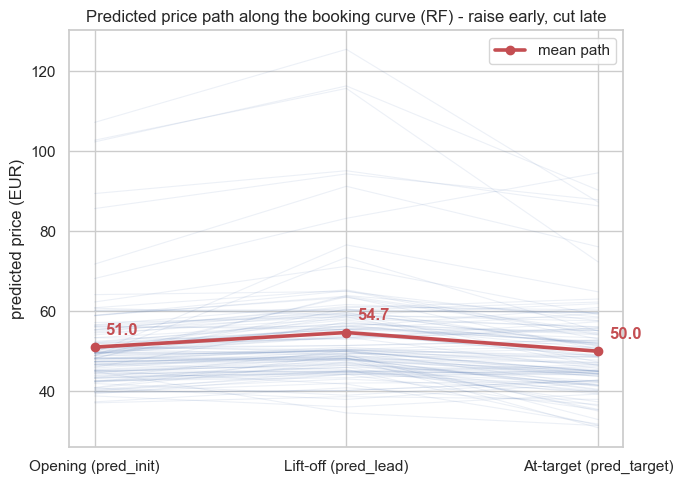

In [16]:
import numpy as np, matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

stages = ["Opening (pred_init)", "Lift-off (pred_lead)", "At-target (pred_target)"]
paths = comparison[["pred_init", "pred_lead", "pred_target"]].to_numpy()
x = np.arange(3)

fig, ax = plt.subplots(figsize=(7, 5))
rng = np.random.default_rng(0)
sample = paths[rng.choice(len(paths), size=min(120, len(paths)), replace=False)]
for row in sample:
    ax.plot(x, row, color="#4c72b0", alpha=0.10, lw=0.8)
means = paths.mean(axis=0)
ax.plot(x, means, color="#c44e52", lw=2.6, marker="o", label="mean path")
for xi, m in zip(x, means):
    ax.annotate(f"{m:.1f}", (xi, m), textcoords="offset points", xytext=(8, 9),
                color="#c44e52", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(stages)
ax.set_ylabel("predicted price (EUR)")
ax.set_title("Predicted price path along the booking curve (RF) - raise early, cut late")
ax.legend()
fig.tight_layout()